     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 8.3 MB/s eta 0:00:00
HMM + KALMAN FILTER — DYNAMIC MARKET REGIME DETECTION

FEATURES USED
---------------------------------------------------------------------------
• Return
• Volatility
• Momentum
• Kalman_Return
• Kalman_Deviation

REGIME STATISTICS
---------------------------------------------------------------------------
 Regime  Observations  Mean Return (%)  Annualized Volatility (%)  Mean Kalman Deviation (%)
   Bear           296          -0.2444                    15.8800                    -0.8028
Neutral          2055           0.0799                    11.2938                     0.6753
   Bull           336           0.0931                    32.9736                    -0.3597

TRANSITION PROBABILITY MATRIX
---------------------------------------------------------------------------
         Ne

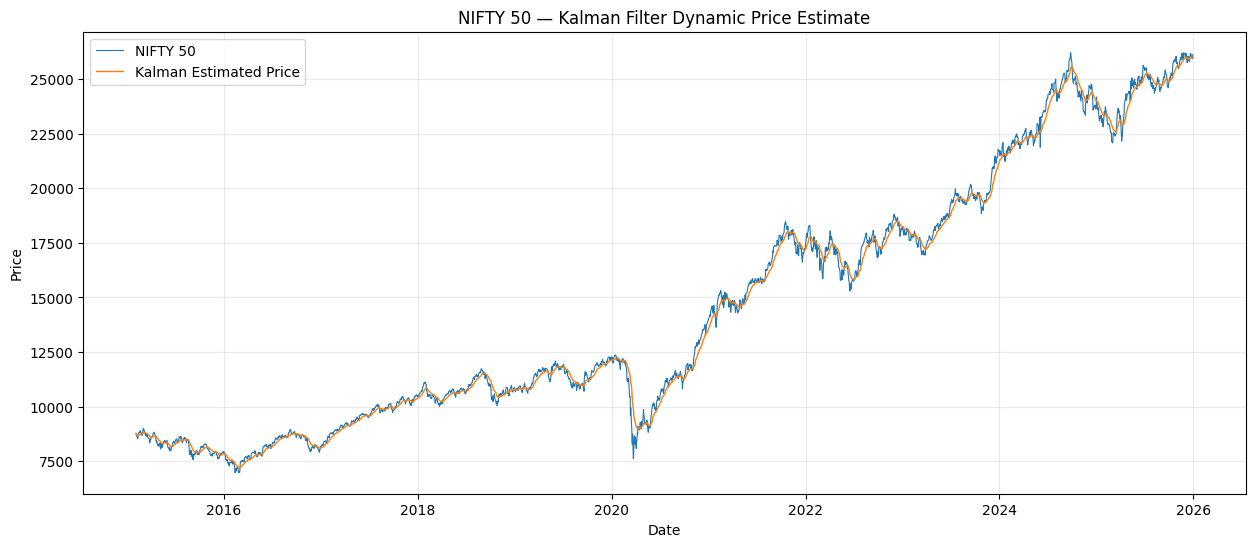

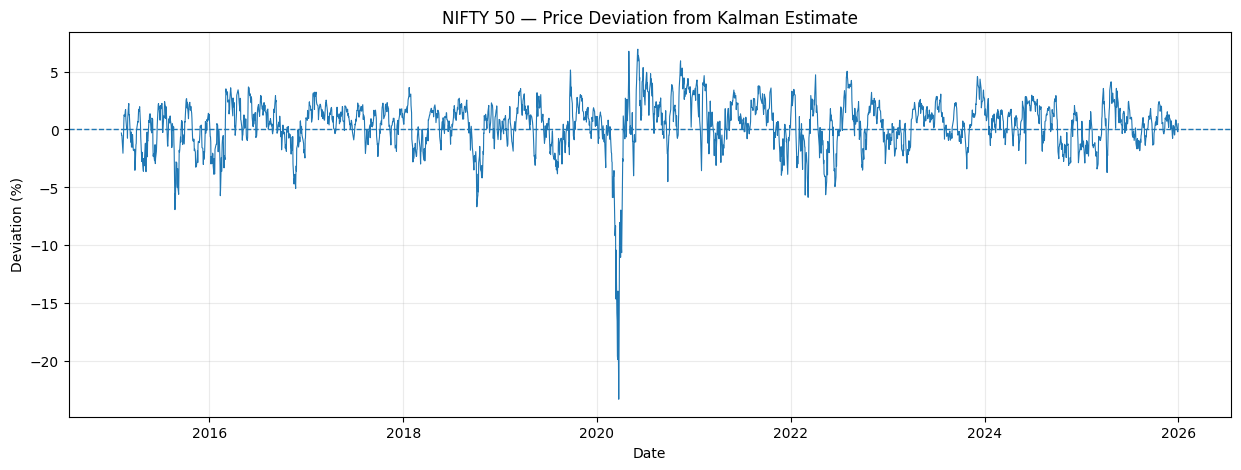

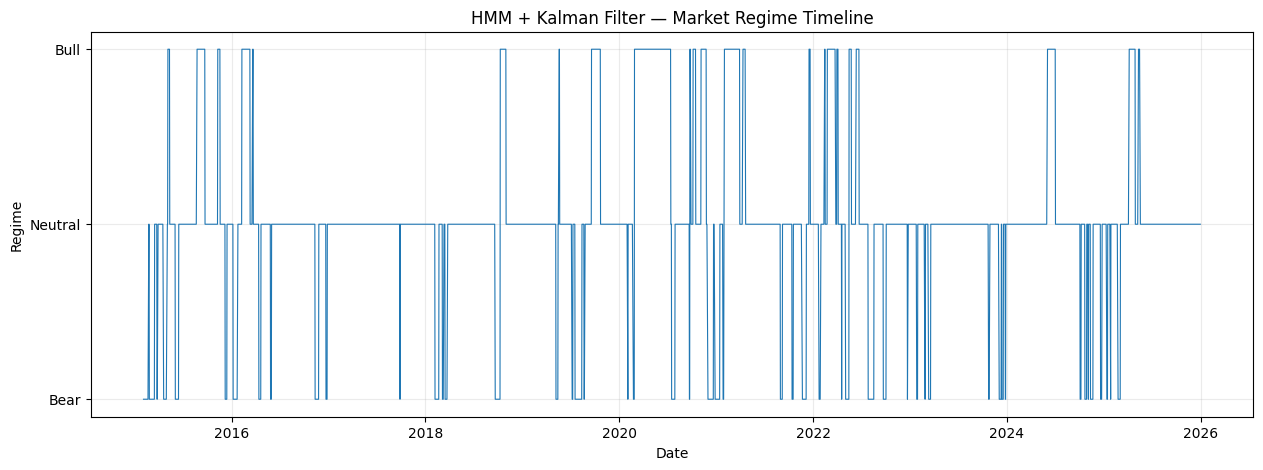

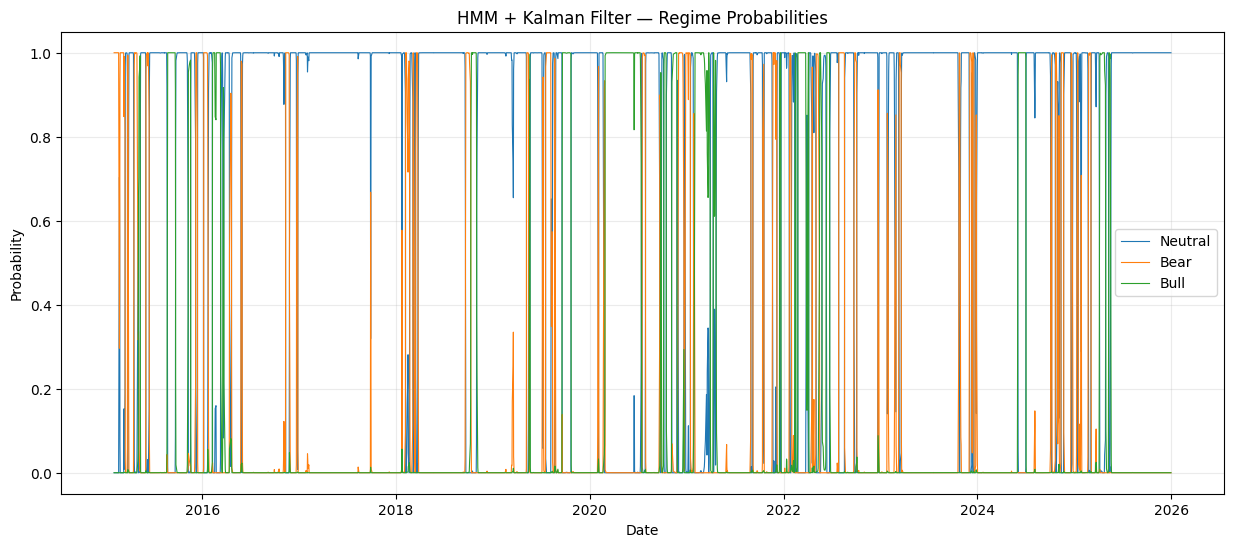


Files saved:
• NIFTY50_HMM_Kalman_Dynamic_Regimes.csv
• HMM_Kalman_Transition_Matrix.csv
• HMM_Kalman_Regime_Persistence.csv


In [1]:
# ============================================================
# PROJECT 7 — HMM + KALMAN FILTER
# DYNAMIC MARKET REGIME DETECTION
# NIFTY 50
# ============================================================

!pip -q install yfinance hmmlearn filterpy scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from hmmlearn.hmm import GaussianHMM
from filterpy.kalman import KalmanFilter
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. DOWNLOAD NIFTY 50 DATA
# ------------------------------------------------------------
df = yf.download(
    "^NSEI",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.dropna()

# ------------------------------------------------------------
# 2. MARKET VARIABLES
# ------------------------------------------------------------
df["Return"] = df["Close"].pct_change()

df["Volatility"] = (
    df["Return"]
    .rolling(20)
    .std()
)

df["Momentum"] = (
    df["Close"] /
    df["Close"].rolling(20).mean() - 1
)

df = df.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

# ------------------------------------------------------------
# 3. KALMAN FILTER
# ------------------------------------------------------------
# Estimate a dynamically changing latent price level.

kf = KalmanFilter(
    dim_x=1,
    dim_z=1
)

kf.x = np.array([
    [df["Close"].iloc[0]]
])

kf.F = np.array([
    [1.]
])

kf.H = np.array([
    [1.]
])

kf.P *= 1.0
kf.R = 1.0
kf.Q = 0.01

kalman_values = []

for price in df["Close"].values:

    kf.predict()
    kf.update(
        np.array([price])
    )

    kalman_values.append(
        float(kf.x[0, 0])
    )

df["Kalman_Price"] = kalman_values

# ------------------------------------------------------------
# 4. KALMAN-BASED DYNAMIC SIGNAL
# ------------------------------------------------------------
df["Kalman_Return"] = (
    df["Kalman_Price"]
    .pct_change()
)

df["Kalman_Deviation"] = (
    df["Close"] /
    df["Kalman_Price"] - 1
)

df = df.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

# ------------------------------------------------------------
# 5. HMM FEATURES
# ------------------------------------------------------------
features = [
    "Return",
    "Volatility",
    "Momentum",
    "Kalman_Return",
    "Kalman_Deviation"
]

scaler = StandardScaler()

X = scaler.fit_transform(
    df[features]
)

# ------------------------------------------------------------
# 6. FIT GAUSSIAN HMM
# ------------------------------------------------------------
n_states = 3

model = GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(X)

df["State"] = model.predict(X)

state_probabilities = (
    model.predict_proba(X)
)

for i in range(n_states):

    df[
        f"State_{i}_Probability"
    ] = state_probabilities[:, i]

# ------------------------------------------------------------
# 7. REGIME IDENTIFICATION
# ------------------------------------------------------------
state_stats = []

for state in range(n_states):

    data = df[
        df["State"] == state
    ]

    state_stats.append({

        "State": state,

        "Mean Return":
            data["Return"].mean(),

        "Volatility":
            data["Return"].std(),

        "Mean Kalman Deviation":
            data["Kalman_Deviation"].mean()

    })

state_stats = pd.DataFrame(
    state_stats
)

# Rank states according to mean return
ordered_states = (
    state_stats
    .sort_values("Mean Return")
    ["State"]
    .tolist()
)

labels = [
    "Bear",
    "Neutral",
    "Bull"
]

state_mapping = {

    ordered_states[i]:
        labels[i]

    for i in range(n_states)
}

df["Regime"] = (
    df["State"]
    .map(state_mapping)
)

# ------------------------------------------------------------
# 8. TRANSITION MATRIX
# ------------------------------------------------------------
transition_matrix = pd.DataFrame(

    model.transmat_,

    index=[
        state_mapping[i]
        for i in range(n_states)
    ],

    columns=[
        state_mapping[i]
        for i in range(n_states)
    ]
)

# ------------------------------------------------------------
# 9. RESULTS
# ------------------------------------------------------------
print("=" * 75)
print("HMM + KALMAN FILTER — DYNAMIC MARKET REGIME DETECTION")
print("=" * 75)

print("\nFEATURES USED")
print("-" * 75)

for feature in features:
    print("•", feature)

print("\nREGIME STATISTICS")
print("-" * 75)

regime_statistics = []

for state in ordered_states:

    data = df[
        df["State"] == state
    ]

    regime_statistics.append({

        "Regime":
            state_mapping[state],

        "Observations":
            len(data),

        "Mean Return (%)":
            data["Return"].mean() * 100,

        "Annualized Volatility (%)":
            data["Return"].std()
            * np.sqrt(252) * 100,

        "Mean Kalman Deviation (%)":
            data["Kalman_Deviation"].mean()
            * 100

    })

regime_statistics = pd.DataFrame(
    regime_statistics
)

print(
    regime_statistics
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 10. TRANSITION MATRIX
# ------------------------------------------------------------
print("\nTRANSITION PROBABILITY MATRIX")
print("-" * 75)

print(
    transition_matrix
    .round(4)
    .to_string()
)

# ------------------------------------------------------------
# 11. CURRENT REGIME
# ------------------------------------------------------------
latest_state = (
    df["State"].iloc[-1]
)

print("\nCURRENT MARKET REGIME")
print("-" * 75)

print(
    "Date:",
    df.index[-1].date()
)

print(
    "Current Regime:",
    state_mapping[latest_state]
)

print("\nCurrent State Probabilities:")

for state in range(n_states):

    print(
        f"{state_mapping[state]}: "
        f"{df[f'State_{state}_Probability'].iloc[-1] * 100:.2f}%"
    )

# ------------------------------------------------------------
# 12. REGIME PERSISTENCE
# ------------------------------------------------------------
persistence = []

for state in range(n_states):

    stay_probability = (
        model.transmat_[state, state]
    )

    switch_probability = (
        1 - stay_probability
    )

    expected_duration = (

        1 / switch_probability

        if switch_probability > 0

        else np.inf
    )

    persistence.append({

        "Regime":
            state_mapping[state],

        "Stay Probability":
            stay_probability,

        "Expected Duration (Days)":
            expected_duration

    })

persistence_df = pd.DataFrame(
    persistence
)

print("\nREGIME PERSISTENCE")
print("-" * 75)

print(
    persistence_df
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 13. KALMAN PRICE VS ACTUAL PRICE
# ------------------------------------------------------------
plt.figure(
    figsize=(15, 6)
)

plt.plot(
    df.index,
    df["Close"],
    linewidth=0.8,
    label="NIFTY 50"
)

plt.plot(
    df.index,
    df["Kalman_Price"],
    linewidth=1.0,
    label="Kalman Estimated Price"
)

plt.title(
    "NIFTY 50 — Kalman Filter Dynamic Price Estimate"
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------------------
# 14. KALMAN DEVIATION
# ------------------------------------------------------------
plt.figure(
    figsize=(15, 5)
)

plt.plot(
    df.index,
    df["Kalman_Deviation"] * 100,
    linewidth=0.8
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "NIFTY 50 — Price Deviation from Kalman Estimate"
)

plt.xlabel("Date")
plt.ylabel("Deviation (%)")

plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------------------
# 15. HMM REGIME TIMELINE
# ------------------------------------------------------------
numeric_regime = (
    df["Regime"]
    .map({
        "Bear": -1,
        "Neutral": 0,
        "Bull": 1
    })
)

plt.figure(
    figsize=(15, 5)
)

plt.plot(
    df.index,
    numeric_regime,
    linewidth=0.8
)

plt.yticks(
    [-1, 0, 1],
    [
        "Bear",
        "Neutral",
        "Bull"
    ]
)

plt.title(
    "HMM + Kalman Filter — Market Regime Timeline"
)

plt.xlabel("Date")
plt.ylabel("Regime")

plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------------------
# 16. HMM STATE PROBABILITIES
# ------------------------------------------------------------
plt.figure(
    figsize=(15, 6)
)

for state in range(n_states):

    plt.plot(
        df.index,
        df[
            f"State_{state}_Probability"
        ],
        linewidth=0.8,
        label=state_mapping[state]
    )

plt.title(
    "HMM + Kalman Filter — Regime Probabilities"
)

plt.xlabel("Date")
plt.ylabel("Probability")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------------------
# 17. SAVE RESULTS
# ------------------------------------------------------------
df.to_csv(
    "NIFTY50_HMM_Kalman_Dynamic_Regimes.csv"
)

transition_matrix.to_csv(
    "HMM_Kalman_Transition_Matrix.csv"
)

persistence_df.to_csv(
    "HMM_Kalman_Regime_Persistence.csv",
    index=False
)

print("\nFiles saved:")
print(
    "• NIFTY50_HMM_Kalman_Dynamic_Regimes.csv"
)
print(
    "• HMM_Kalman_Transition_Matrix.csv"
)
print(
    "• HMM_Kalman_Regime_Persistence.csv"
)